<a href="https://colab.research.google.com/github/Francisco-Alfredo/Olist-Ecommerce-End-to-End-Analysis/blob/main/An%C3%A1lise_de_Dados_de_e%E2%80%91commerce_olist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **End-to-End Analysis**

In [90]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# **Load the all Files**

In [91]:
#Montar o google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [92]:
# Definir o caminho da pasta no drive
folder = '/content/drive/MyDrive/base de dados/olistdatabase'

In [93]:
files = os.listdir(folder)
files

['olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv',
 'olist_orders_dataset.csv',
 'olist_order_reviews_dataset.csv']

In [94]:
df_customers = pd.read_csv("/content/drive/MyDrive/base de dados/olistdatabase/olist_customers_dataset.csv")
df_geolocation = pd.read_csv("/content/drive/MyDrive/base de dados/olistdatabase/olist_geolocation_dataset.csv")
df_payments = pd.read_csv("/content/drive/MyDrive/base de dados/olistdatabase/olist_order_payments_dataset.csv")
df_order_items = pd.read_csv("/content/drive/MyDrive/base de dados/olistdatabase/olist_order_items_dataset.csv")
df_products = pd.read_csv("/content/drive/MyDrive/base de dados/olistdatabase/olist_products_dataset.csv")
df_products = pd.read_csv("/content/drive/MyDrive/base de dados/olistdatabase/olist_products_dataset.csv")
df_sellers = pd.read_csv("/content/drive/MyDrive/base de dados/olistdatabase/olist_sellers_dataset.csv")
df_product_category = pd.read_csv("/content/drive/MyDrive/base de dados/olistdatabase/product_category_name_translation.csv")
df_orders = pd.read_csv("/content/drive/MyDrive/base de dados/olistdatabase/olist_orders_dataset.csv")
df_order_reviews = pd.read_csv("/content/drive/MyDrive/base de dados/olistdatabase/olist_order_reviews_dataset.csv")

In [95]:
# Check the Size of all files
print(f'orders:{len(df_orders): ,}')
print(f'geolocation:{len(df_geolocation): ,}')
print(f'order_items:{len(df_order_items): ,}')
print(f'order_payments:{len(df_payments): ,}')
print(f'order_reviews:{len(df_order_reviews): ,}')
print(f'product:{len(df_products): ,}')
print(f'sellers:{len(df_sellers): ,}')
print(f'product_category:{len(df_product_category): ,}')
print(f'customer:{len(df_customers): ,}')

orders: 99,441
geolocation: 1,000,163
order_items: 112,650
order_payments: 103,886
order_reviews: 99,224
product: 32,951
sellers: 3,095
product_category: 71
customer: 99,441


In [96]:
df_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [97]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [98]:
date_col = ['order_purchase_timestamp',	'order_approved_at',
            'order_delivered_carrier_date',	'order_delivered_customer_date',
            'order_estimated_delivery_date']
for col in date_col:
    df_orders[col] = pd.to_datetime(df_orders[col], errors = 'coerce')

In [99]:
df_orders.dtypes

,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


In [100]:
# Audit-just observe, touch nothing
print("=== Null Audit===")
null_report = pd.DataFrame({
    'null_count' : df_orders.isnull().sum(),
    'null_percentage' : (df_orders.isnull().sum()/len(df_orders)*100).round(2)
})
print(null_report[null_report['null_count']>0])

# Why are they null?, read it as story
print("\n=== WHY ARE THEY NULL? ===")
print(df_orders['order_status'].value_counts())
# delivered_date is null because order is cancelled/shipped/processing
# That is VALID data — not an error

=== Null Audit===
                               null_count  null_percentage
order_approved_at                     160             0.16
order_delivered_carrier_date         1783             1.79
order_delivered_customer_date        2965             2.98

=== WHY ARE THEY NULL? ===
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [101]:
df_product_category.columns

Index(['product_category_name', 'product_category_name_english'], dtype='object')

In [102]:
df_products.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

In [103]:
df_customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

In [104]:
df_order_reviews.columns

Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')

In [105]:
df_order_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

In [106]:
df_payments.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')

In [107]:
df_product_category.columns

Index(['product_category_name', 'product_category_name_english'], dtype='object')

In [108]:
df = (
    df_orders
    .merge(df_customers[['customer_id','customer_city', 'customer_state']], on = 'customer_id', how = 'left')
            .merge(df_order_items[['order_id','product_id','seller_id','price', 'freight_value']],on = 'order_id', how = 'left')
            .merge(df_payments[['order_id','payment_type', 'payment_value']], on = 'order_id', how= 'left')
            .merge(df_order_reviews[['order_id','review_score','review_comment_title','review_comment_message']], on = 'order_id', how = 'left')
        .merge(df_products[['product_id', 'product_category_name']], on = 'product_id', how = 'left')
                   .merge(df_product_category, on = 'product_category_name', how ='left')
                  )
df.rename(columns={'product_category_name_english':'product_category_en'}, inplace=True)
print(f'Olist Shape:{df.shape}')
df.head()

Olist Shape:(119143, 21)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,...,seller_id,price,freight_value,payment_type,payment_value,review_score,review_comment_title,review_comment_message,product_category_name,product_category_en
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,sao paulo,SP,...,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,credit_card,18.12,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",utilidades_domesticas,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,sao paulo,SP,...,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,voucher,2.00,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",utilidades_domesticas,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,sao paulo,SP,...,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,voucher,18.59,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",utilidades_domesticas,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,barreiras,BA,...,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,boleto,141.46,4.0,Muito boa a loja,Muito bom o produto.,perfumaria,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,vianopolis,GO,...,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,credit_card,179.12,5.0,NaN,NaN,automotivo,auto


In [109]:
df['order_status'].value_counts()

,count
order_status,
delivered,115723
shipped,1256
canceled,750
unavailable,652
invoiced,378
processing,376
created,5
approved,3


In [110]:
# check delivery status(actual)
df['delivery_days'] = (df['order_delivered_customer_date']- df['order_purchase_timestamp']).dt.days

# Delay (positive = late, negative = early)
df['delivery_delay'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
# Total order value
df['Total_price_value'] = df['price'] + df['freight_value']
# Order month/year for trend analysis
df['order_month'] = df['order_purchase_timestamp'].dt.to_period("M")
df['order_year'] = df['order_purchase_timestamp'].dt.year

delivered_count = (df['order_status'] == 'delivered').sum()
print(f"Total delivered orders        : {delivered_count:,}")
print(f"Rows with valid delivery_days : {df['delivery_days'].notna().sum():,}")
print(f"Rows with NaN delivery_days   : {df['delivery_days'].isna().sum():,}")

Total delivered orders        : 115,723
Rows with valid delivery_days : 115,722
Rows with NaN delivery_days   : 3,421


In [111]:
df[df['delivery_delay'] > 60].shape and df[df['delivery_days'] > 60].shape

(328, 26)

# **KPI**

**1.1 Average review score by product category**

In [112]:
# Average review score by product category
avg_score = df.groupby('product_category_en')['review_score'].mean().reset_index()
avg_score.columns= ['category', 'avg_score']
avg_score.sort_values('avg_score', ascending = False)
print(avg_score.head(10))

                     category  avg_score
0  agro_industry_and_commerce   4.150794
1            air_conditioning   3.969697
2                         art   3.935484
3       arts_and_craftmanship   4.125000
4                       audio   3.840849
5                        auto   4.064279
6                        baby   4.011643
7              bed_bath_table   3.890605
8      books_general_interest   4.438503
9              books_imported   4.419355


In [113]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_city', 'customer_state', 'product_id', 'seller_id', 'price',
       'freight_value', 'payment_type', 'payment_value', 'review_score',
       'review_comment_title', 'review_comment_message',
       'product_category_name', 'product_category_en', 'delivery_days',
       'delivery_delay', 'Total_price_value', 'order_month', 'order_year'],
      dtype='object')

In [114]:
df['payment_type'].value_counts()

,count
payment_type,
credit_card,87776
boleto,23190
voucher,6465
debit_card,1706
not_defined,3


**1.2 Payment type and Review score distribution**

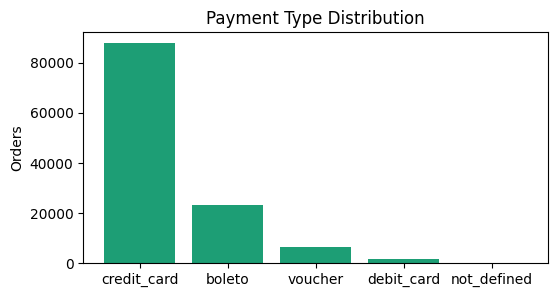

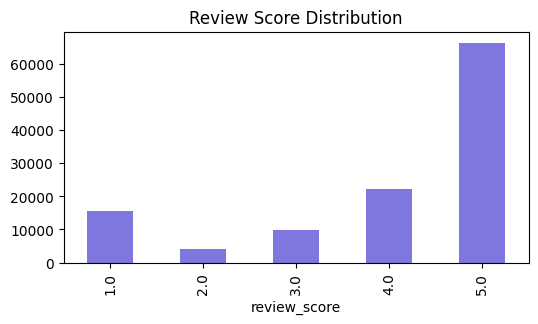

In [115]:
# Payment type distribution
payment_dist = df['payment_type'].value_counts().reset_index()
payment_dist.columns = ['category', 'count']
plt.figure(figsize =(6,3))
plt.bar(payment_dist['category'],payment_dist['count'], color = '#1D9E75')
plt.title('Payment Type Distribution')
plt.ylabel('Orders')
plt.show()

# Review score distribution
df['review_score'].value_counts().sort_index().plot(
    kind='bar', color='#7F77DD', figsize=(6,3), title='Review Score Distribution'
)
plt.show()

**1.3 Monthly Revenue Trend Analysis**

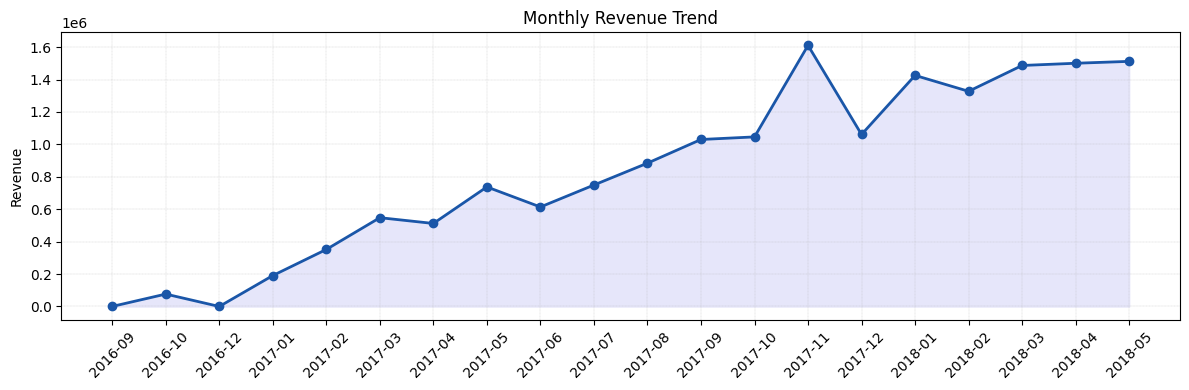

In [116]:
# Monthly Revenue Trend Analysis
monthly_revenue = df.groupby(df['order_month'])['payment_value'].sum().reset_index().head(20)
monthly_revenue['order_month'] = monthly_revenue['order_month'].astype(str)
plt.figure(figsize = (12,4))
plt.plot(monthly_revenue['order_month'], monthly_revenue['payment_value'], marker = 'o', linewidth =2,  color= '#1A56A8')
plt.xticks(rotation = 45)
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")
plt.fill_between(monthly_revenue['order_month'], monthly_revenue['payment_value'], color = '#E6E6FA')
plt.grid(linestyle = '--', linewidth = 0.2)
plt.tight_layout()
plt.show()

As you see year 2017 and month November(11) show the highest monthly revenue, The overall trend shows positive growth with the peak in late 2017, followed by the fluctuations and a notable drop the late 2018.

**1.4(a) On-Time Delivery Rate**

In [117]:
#  On-Time Delivery Rate
on_time = (df['delivery_delay'] <=0).sum()
late = (df['delivery_delay'] >0).sum()
total_del = len(df['delivery_delay'])

on_time_rate = (on_time/total_del)*100
avg_delay = df[df['delivery_delay'] > 0]['delivery_delay'].mean()

print(f"On-Time Delivery Rate :  {on_time_rate: .1f}%")
print(f"Late Order            :   {late:,} ({100-on_time_rate:.1f}%)")
print(f"Avg Delay(late only)  :  {avg_delay: .1f} days")

On-Time Delivery Rate :   90.8%
Late Order            :   7,559 (9.2%)
Avg Delay(late only)  :   10.6 days


**1.4(b) Monthly On-Time Delivery**

In [119]:
# Monthly On-Time Delivery
df['order_month'] = df['order_purchase_timestamp'].dt.to_period("M")
monthly = df.groupby('order_month').apply(
    lambda x: (x['delivery_delay'] <=0).mean()*100, include_groups = False).reset_index()
monthly.columns = ['order_month', 'on_time_pct']
monthly['month_str'] = monthly['order_month'].astype(str)

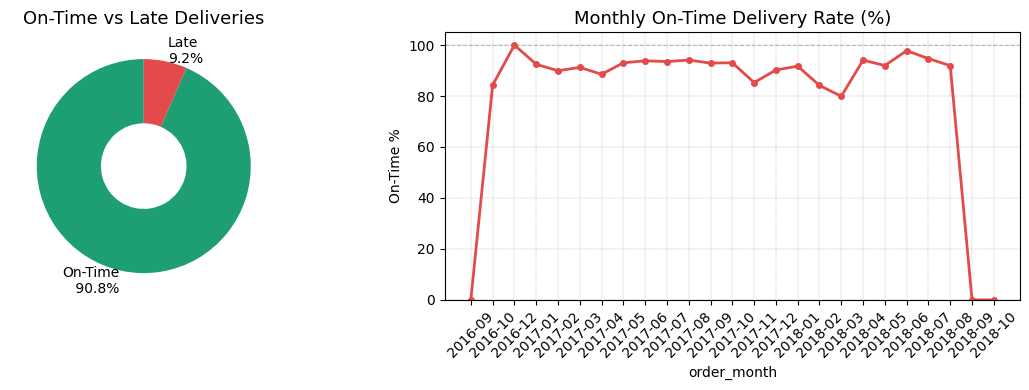

In [120]:
# subplots of deliveries
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie([on_time, late],
            labels= [f"On-Time\n{on_time_rate: .1f}%",
                     f"Late\n{100-on_time_rate:.1f}%"],
            colors =['#1D9E75', '#E24B4A'],
            startangle =90, wedgeprops=dict(width=0.6)
)

axes[0].set_title('On-Time vs Late Deliveries', fontsize =13)


axes[1].plot(monthly['month_str'], monthly['on_time_pct'],
             color= '#E24B4A', linewidth=2, marker='o', markersize=4)
axes[1].axhline(100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

axes[1].set_title('Monthly On-Time Delivery Rate (%)', fontsize=13)
axes[1].set_xlabel('order_month'); axes[1].set_ylabel('On-Time %')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.grid(linewidth = 0.3, linestyle = '--')
plt.show()


**1.5 Order Cancellation Rate**

In [121]:
# Order Cancellation Rate
status_counts = df['order_status'].value_counts()
total_orders = len(df)
cancelled = status_counts.get('canceled', 0)
cancel_rate = (cancelled/total_orders)*100
print(f"Total Orders :  {total_orders:,}")
print(f"Cancelled Orders : {cancelled:,}")
print(f"Cancellation Rate : {cancel_rate: .2f}%")
print("\n---Full status breakdown:---")
print(status_counts)

Total Orders :  119,143
Cancelled Orders : 750
Cancellation Rate :  0.63%

---Full status breakdown:---
order_status
delivered      115723
shipped          1256
canceled          750
unavailable       652
invoiced          378
processing        376
created             5
approved            3
Name: count, dtype: int64


**1.6 Monthly cancellation trend**

In [122]:
# Monthly cancellation trend
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly_cancel= df.groupby('order_month').apply(
    lambda x:(x['order_status']=='canceled').mean()*100, include_groups = False
).reset_index()
monthly_cancel.columns = ['month', 'cancel_pct']
monthly_cancel['month_str'] = monthly_cancel['month'].astype(str)

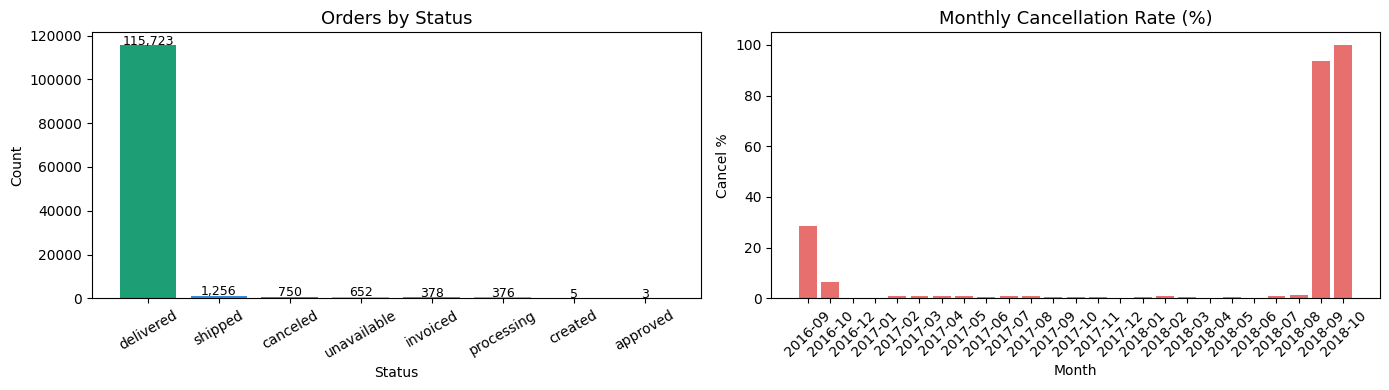

In [123]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors_map = {
    'delivered'  : '#1D9E75',
    'shipped'    : '#378ADD',
    'canceled'   : '#E24B4A',
    'processing' : '#EF9F27',
    'invoiced'   : '#7F77DD',
    'approved'   : '#5DCAA5',
    'unavailable': '#B4B2A9',
}

bar_colors = [colors_map.get(s, '#888780') for s in status_counts.index]
axes[0].bar(status_counts.index, status_counts.values, color=bar_colors)
axes[0].set_title('Orders by Status', fontsize=13)
axes[0].set_xlabel('Status'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)


# Monthly cancellation trend
axes[1].bar(monthly_cancel['month_str'], monthly_cancel['cancel_pct'],
             color='#E24B4A', alpha=0.8)
axes[1].set_title('Monthly Cancellation Rate (%)', fontsize=13)
axes[1].set_xlabel('Month'); axes[1].set_ylabel('Cancel %')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Distribution of City Delay**

In [124]:
city_delay = df.groupby('customer_city')['delivery_days'].sum().reset_index().sort_values('delivery_days',ascending = False).head(10)
city_delay

,customer_city,delivery_days
3597,sao paulo,138415.0
3155,rio de janeiro,114593.0
453,belo horizonte,34200.0
558,brasilia,30418.0
3247,salvador,27801.0
2964,porto alegre,25122.0
1143,curitiba,17861.0
707,campinas,15918.0
1374,fortaleza,14548.0
2461,niteroi,14499.0


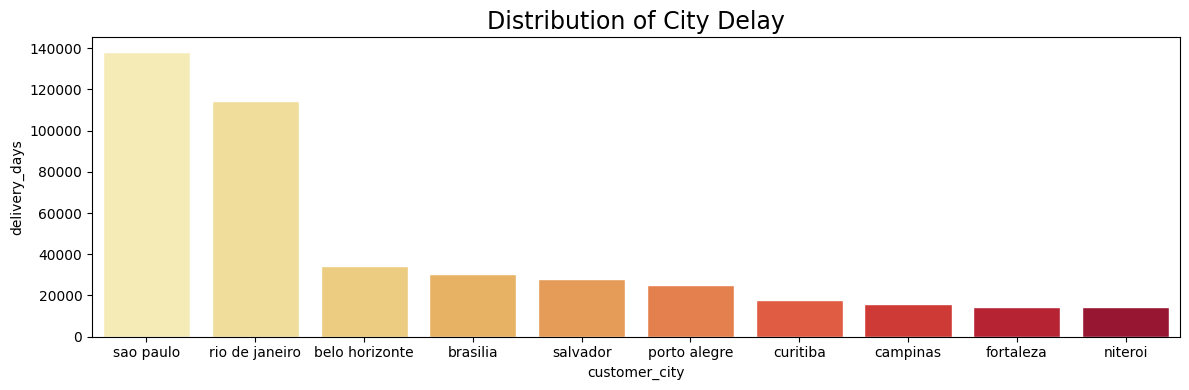

In [125]:
plt.figure(figsize = (12, 4))
palette = sns.color_palette("YlOrRd", len(city_delay))
bar = sns.barplot(data = city_delay, x = 'customer_city', y = 'delivery_days',
                  hue = 'customer_city',
                      palette = palette,
                  legend = False,
                      edgecolor = 'white'
                      )
plt.title('Distribution of City Delay', fontsize = 17)
plt.tight_layout()
plt.show()

Its clearly visible that Sao Paulo and Rio de Janeiro have significantly higher delivery days compared to other cities, cities like Belo Horizonte, Brasilia, and Salvador fall into the mid-range category with moderate delivery days. Meanwhile, Cruitiba, Campinas, Fortaleza, and Niteroi shows lower delivery days, suggesting more efficient deliveries or fewer orders.

All distribution is highly skewed, with a few major cities contributing the majority of delivery delays.